## News headline analysis: word frequency and topic trends

##### Name : Nupur Makwana
##### Roll no: 02414702024 
##### Class : BCA 4th Semester 
##### Date : 4th May 2026
##### Instructor Name : Dr. Charul Nigam

## Objective and Problem Statement 

##### Analyze news data to identify kep topics , word patterns and how trends change over time.`

## Import Libraries 

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


## Load Data

In [38]:
news_data = pd.read_csv("./data/news_dataset.csv")

print("The News Data ---->")
news_data.head()

The News Data ---->


,date,title,content,source
0,11.05.2025,Education: Light able sport career six discuss...,Education is showing significant market shift ...,Economic Times
1,13.04.2025,Stock Market: Join tough former nice quite.,Stock Market is showing significant rise in re...,Reuters
2,15.04.2025,Elections: Citizen item particularly short wha...,Elections is showing significant growth in rec...,Economic Times
3,07.09.2025,Jobs Market: Themselves business coach million...,Jobs Market is showing significant growth in r...,NDTV
4,08.03.2025,Space Exploration: Eat wonder political return...,Space Exploration is showing significant growt...,BBC News


In [39]:
print("Shape of Data ---->")
print(news_data.shape)

Shape of Data ---->
(300, 4)


In [40]:
print("Info of Data ---->")
print(news_data.info())

Info of Data ---->
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date     300 non-null    object
 1   title    300 non-null    object
 2   content  300 non-null    object
 3   source   300 non-null    object
dtypes: object(4)
memory usage: 9.5+ KB
None


In [41]:
print("Using describe() on Data ---->")
print(news_data.describe())

Using describe() on Data ---->
              date                                              title  \
count          300                                                300   
unique         212                                                300   
top     07.12.2025  Education: Light able sport career six discuss...   
freq             4                                                  1   

                                                  content          source  
count                                                 300             300  
unique                                                300              12  
top     Education is showing significant market shift ...  Times of India  
freq                                                    1              32  


## Data Cleaning and Preprocessing

#### Handle Missing Values 

In [ ]:
news_data.dropna(inplace = True)

In [14]:
print(news_data.isnull().sum())

#The Data does not contain any missing values.

date       0
title      0
content    0
source     0
dtype: int64


#### Remove Duplicates

In [ ]:
news_data.drop_duplicates(subset=None, *, keep='first', inplace=True, ignore_index=True)

In [15]:
print(news_data.duplicated().sum())

#The Data does not contain any duplicated values.

0


#### Correcting Data Types

In [18]:
print(news_data.dtypes)

date       object
title      object
content    object
source     object
dtype: object


In [42]:
news_data['date'] = pd.to_datetime(news_data['date'],format='%d.%m.%Y')
news_data['title'] = news_data['title'].astype('str')
news_data['content'] = news_data['content'].astype('str')
news_data['source'] = news_data['source'].astype('str')

In [43]:
print(news_data.dtypes)

#Datatype for each column changed respective of their content.

date       datetime64[ns]
title              object
content            object
source             object
dtype: object


#### Converting text to lowercase

In [44]:
news_data['title']= news_data['title'].map(lambda x: x.lower())
news_data['content']= news_data['content'].map(lambda x: x.lower())
news_data['source']= news_data['source'].map(lambda x: x.lower())

In [45]:
news_data.head()

#Text converted to lowercase for better analysis .

,date,title,content,source
0,2025-05-11,education: light able sport career six discuss...,education is showing significant market shift ...,economic times
1,2025-04-13,stock market: join tough former nice quite.,stock market is showing significant rise in re...,reuters
2,2025-04-15,elections: citizen item particularly short wha...,elections is showing significant growth in rec...,economic times
3,2025-09-07,jobs market: themselves business coach million...,jobs market is showing significant growth in r...,ndtv
4,2025-03-08,space exploration: eat wonder political return...,space exploration is showing significant growt...,bbc news


#### Remove punctuation/special characters and stopwords

#### Create new clean title and clean content column

In [46]:
'''import nltk 
nltk.download('stopwords')'''  # Dowloading nltk , stopwords removes a list of common words like(this,is , and) and focus of meaningful words

import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z ]','',text) #removes punctutation , used to clean text by using patterns
    words = text.split() #tokenize
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

news_data['clean title'] = news_data['title'].apply(clean_text)
news_data['clean content'] = news_data['content'].apply(clean_text)

In [47]:
news_data.head()

#Cleaned column for  title and content generated removing punctuation and stopwords

,date,title,content,source,clean title,clean content
0,2025-05-11,education: light able sport career six discuss...,education is showing significant market shift ...,economic times,education light able sport career six discuss ...,education showing significant market shift rec...
1,2025-04-13,stock market: join tough former nice quite.,stock market is showing significant rise in re...,reuters,stock market join tough former nice quite,stock market showing significant rise recent r...
2,2025-04-15,elections: citizen item particularly short wha...,elections is showing significant growth in rec...,economic times,elections citizen item particularly short what...,elections showing significant growth recent re...
3,2025-09-07,jobs market: themselves business coach million...,jobs market is showing significant growth in r...,ndtv,jobs market business coach million always,jobs market showing significant growth recent ...
4,2025-03-08,space exploration: eat wonder political return...,space exploration is showing significant growt...,bbc news,space exploration eat wonder political return ...,space exploration showing significant growth r...


#### Saving the file

In [48]:
news_data.to_csv("cleaned_news_data.csv", index=False)

In [43]:
#Cleaned data saved into a new csv file

## EDA : Exploratory Data Analysis

## Counting Words Frequency 

In [49]:
news_data['final text'] = news_data['clean title'] + news_data['clean content']
news_data['final text'].head()

0    education light able sport career six discuss ...
1    stock market join tough former nice quitestock...
2    elections citizen item particularly short what...
3    jobs market business coach million alwaysjobs ...
4    space exploration eat wonder political return ...
Name: final text, dtype: object

In [50]:
import collections
from collections import Counter

all_words = " ".join(news_data['final text'])
words = all_words.split()

word_freq = Counter(words)
print(word_freq.most_common(50))

[('global', 352), ('reports', 323), ('recent', 309), ('situation', 309), ('significant', 308), ('current', 308), ('may', 306), ('suggest', 304), ('showing', 300), ('experts', 300), ('influence', 300), ('markets', 300), ('policies', 300), ('market', 108), ('innovation', 65), ('economy', 57), ('policy', 47), ('exploration', 36), ('impact', 36), ('change', 35), ('analysis', 33), ('rise', 30), ('intelligence', 30), ('regulation', 30), ('decline', 29), ('vehicles', 28), ('growth', 27), ('space', 27), ('trends', 27), ('shift', 26), ('concerns', 26), ('education', 23), ('ecosystem', 22), ('media', 21), ('technology', 21), ('stock', 20), ('elections', 20), ('jobs', 20), ('relations', 20), ('changes', 20), ('cricket', 19), ('social', 19), ('opportunities', 18), ('bar', 16), ('government', 16), ('focus', 15), ('despite', 15), ('job', 15), ('great', 15), ('artificial', 15)]


### A visual representing 50 common words with highest frequency

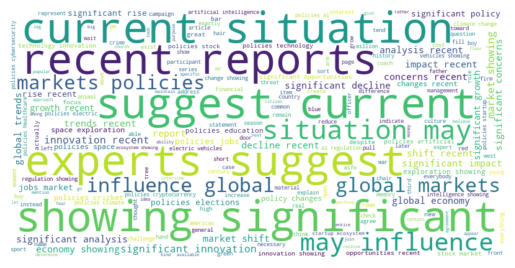

In [51]:
'''!pip install wordcloud'''
from wordcloud import WordCloud
wc = WordCloud(width=800, height=400, background_color='white').generate(all_words)
fig, ax = plt.subplots() # Create figure
ax.imshow(wc, interpolation='bilinear')
ax.axis("off")
plt.show()

# Saving figure
fig.savefig("wordcloud.png")

### Bar Chart representing  Top 20 words 

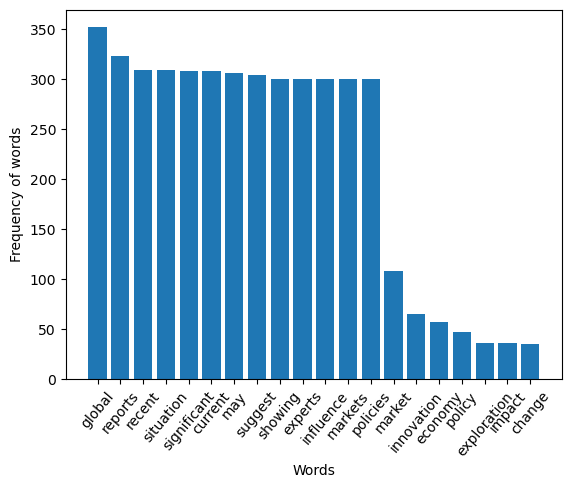

In [52]:
common = word_freq.most_common(20)

words = [w[0] for w in common]
counts = [w[1] for w in common]

plt.bar(words,counts)
plt.xticks(rotation = 50)
plt.ylabel("Frequency of words")
plt.xlabel("Words")
plt.show()

###### Insight : The most frequent words like global, market, economy, policy, and change indicate that the news dataset is heavily focused on economic and global developments. 
###### Words such as experts, suggest, report show a strong presence of analytical or opinion-based reporting. 
###### Repetition of terms like market and policy suggests these are dominant themes across multiple articles. 
###### Overall, the dataset reflects macro-level discussions rather than niche topics, highlighting trends related to economy and global impact.

## Trend Analysis

#### Trend Analysis for word : ai

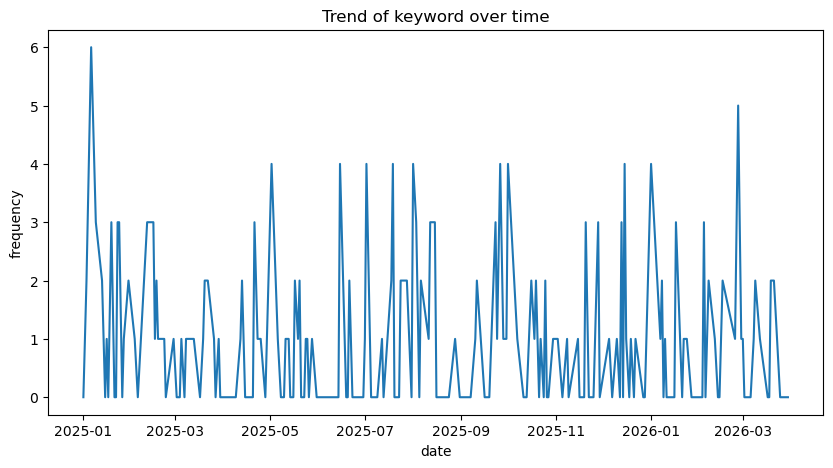

In [53]:
keyword = "ai" 
news_data['keyword count'] = news_data['final text'].apply(lambda x: x.count(keyword))
trend = news_data.groupby(news_data['date'].dt.date)['keyword count'].sum()
trend.plot(figsize=(10,5))
plt.ylabel("frequency")
plt.title("Trend of keyword over time")
plt.show()

#### Interpretation:
AI appears in the news dataset in bursts, likely tied to specific events (e.g., product launches, policy news, major announcements).
The lack of a smooth trend suggests it’s not steadily growing in coverage within this dataset, but instead spikes when something notable happens. 

#### Trend Analysis for word : economy

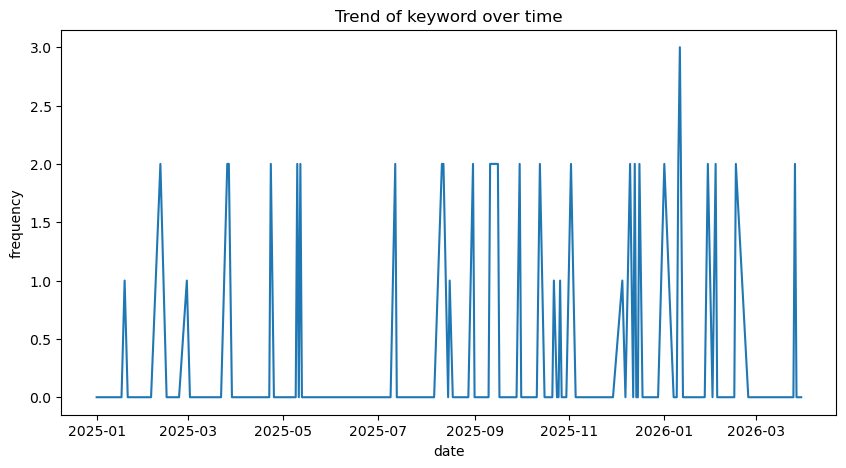

In [54]:
keyword = "economy" 
news_data['keyword count'] = news_data['final text'].apply(lambda x: x.count(keyword))
trend = news_data.groupby(news_data['date'].dt.date)['keyword count'].sum()

trend.plot(figsize=(10,5))
plt.ylabel("frequency")
plt.title("Trend of keyword over time")
plt.show()

#### Interpretation:
The graph shows that mentions of “economy” fluctuate sharply over time, with frequent ups and downs.
Most days have low or zero mentions, indicating limited consistent coverage.
Occasional spikes suggest increased attention during major economic events or announcements.
Overall, the trend is irregular and event-driven, with no clear long-term increase or decrease.

#### Trend Analysis for word : cricket

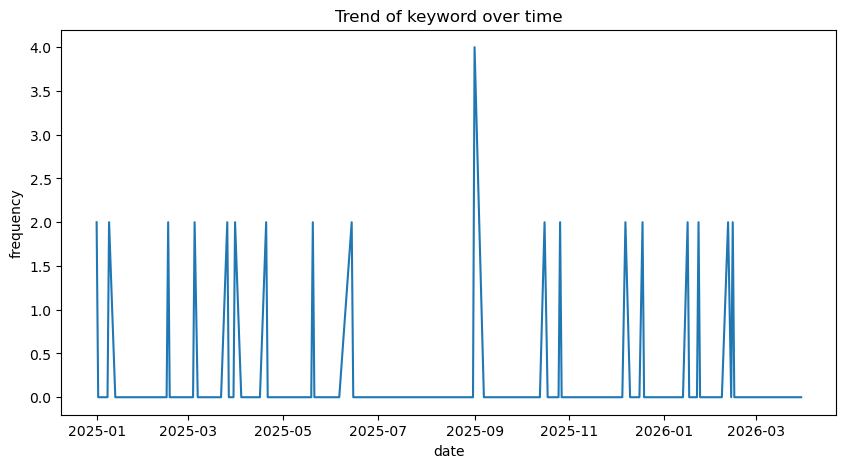

In [55]:
keyword = "cricket" 
news_data['keyword count'] = news_data['final text'].apply(lambda x: x.count(keyword))
trend = news_data.groupby(news_data['date'].dt.date)['keyword count'].sum()

trend.plot(figsize=(10,5))
plt.ylabel("frequency")
plt.title("Trend of keyword over time")
plt.show()

#### Interpretation:
The graph shows that mentions of “cricket” are mostly low, with many days having zero coverage.
There are occasional small spikes, indicating brief periods of attention.
A noticeable peak around mid-period suggests a major cricket-related event or news.
Overall, coverage is sparse and highly event-driven with no consistent trend.

#### Trend Analysis for word : health

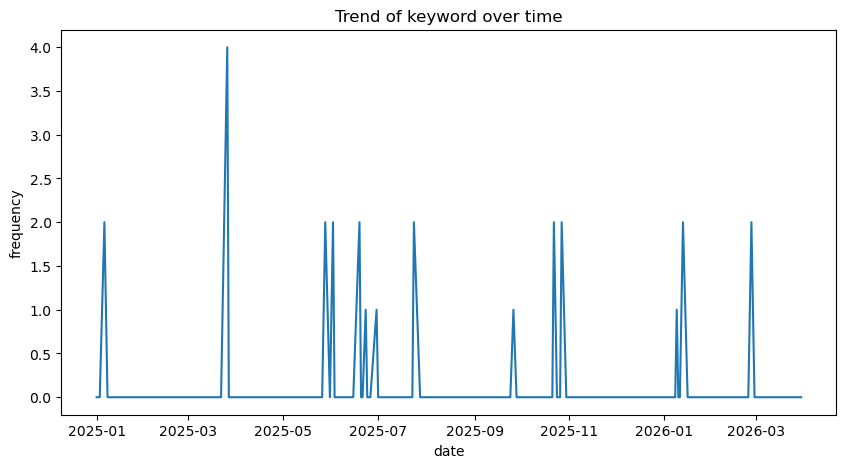

In [56]:
keyword = "health" 
news_data['keyword count'] = news_data['final text'].apply(lambda x: x.count(keyword))
trend = news_data.groupby(news_data['date'].dt.date)['keyword count'].sum()

trend.plot(figsize=(10,5))
plt.ylabel("frequency")
plt.title("Trend of keyword over time")
plt.show()

#### Interpretation:
The graph for “health” shows mostly low and irregular mentions over time, with many days having little to no coverage.
There are occasional spikes, indicating periods when health-related news becomes more prominent, possibly due to outbreaks, reports, or policy updates.
Compared to more consistently discussed topics, “health” appears less frequent but still periodically important in the dataset.
Overall, the trend suggests event-driven coverage with no steady increase or decline, but slightly more relevance during specific time windows.

#### Trend Analysis for word : technology

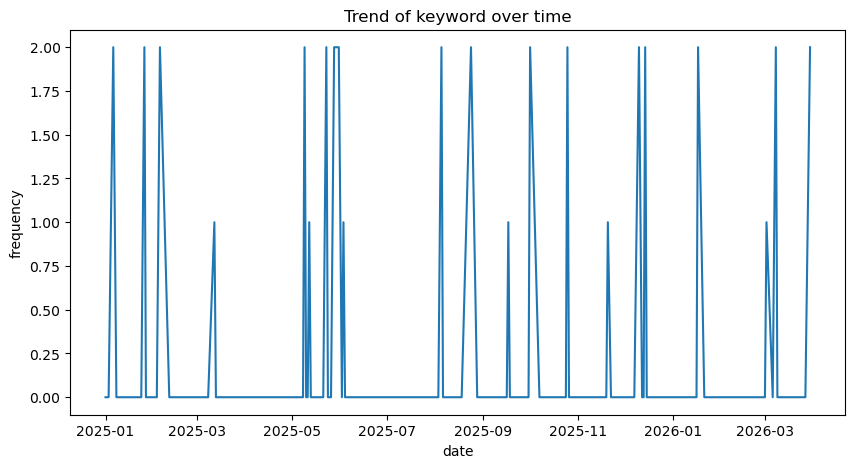

In [57]:
keyword = "technology" 
news_data['keyword count'] = news_data['final text'].apply(lambda x: x.count(keyword))
trend = news_data.groupby(news_data['date'].dt.date)['keyword count'].sum()

trend.plot(figsize=(10,5))
plt.ylabel("frequency")
plt.title("Trend of keyword over time")
plt.show()

#### Interpretation:
The keyword “technology” shows irregular spikes with long periods of low or no activity. This means it appears in news mainly during specific events (like launches or major updates) rather than as a steady trend. Overall, it is event-driven, not consistently trending.

No sustained upward or downward trend: The spikes are scattered across the entire period (2025–early 2026), without a clear increase or decrease over time. This suggests that interest in “technology” is event-driven rather than trend-driven.

Clustered bursts: Some spikes appear close together (e.g., mid-2025, late-2025). This could correspond to cycles like:

Tech conferences or industry events

Regulatory news (AI, data privacy, etc.)

Earnings seasons for major tech companies

## Visualization of complete keywords chosen`

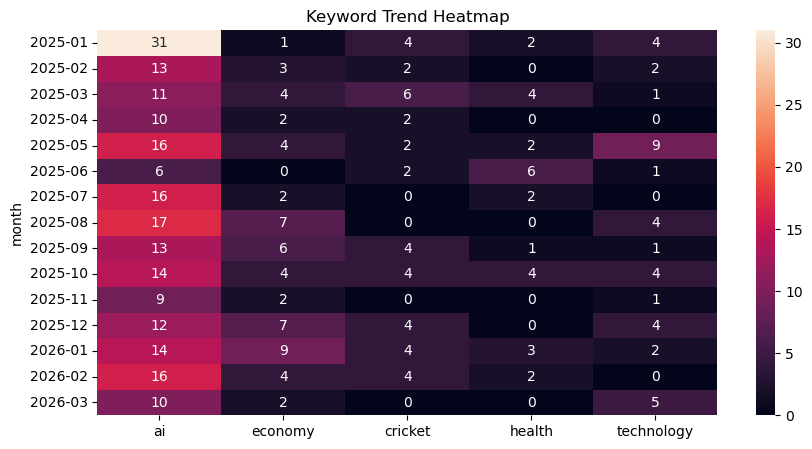

In [58]:
import seaborn as sns
keywords = ["ai", "economy", "cricket", "health", "technology"]

# convert date
news_data['month'] = news_data['date'].dt.to_period('M')

# count keywords
for k in keywords:
    news_data[k] = news_data['final text'].apply(lambda x: x.lower().count(k))

# group by month
heatmap_data = news_data.groupby('month')[keywords].sum()

# plot
plt.figure(figsize=(10,5))
sns.heatmap(heatmap_data, annot=True, fmt="d")
plt.title("Keyword Trend Heatmap")
plt.show()

#### Interpretation:
This heatmap shows how different keywords appear in news across months from early 2025 to early 2026. A few clear patterns stand out:

AI dominates consistently:
The “AI” keyword has the highest values almost every month, peaking strongly at the start of 2025 and remaining relatively high throughout. This suggests AI is a consistently trending and widely covered topic, not just event-driven.

Economy shows moderate, stable interest:
“Economy” appears regularly but at lower levels than AI. There are occasional increases (e.g., mid and late 2025, early 2026), indicating steady but less intense coverage, likely tied to financial updates or policy changes.

Cricket is seasonal/event-based:
The “cricket” keyword has sporadic spikes and several months with zero activity. This reflects tournament-driven coverage, where attention rises during matches or major events and drops afterward.

Health has low and irregular coverage:
“Health” appears infrequently, with mostly low values and some zero months. This suggests it is not a primary focus during this period unless specific issues arise.

Technology is inconsistent and event-driven:
“Technology” shows fluctuating activity, with occasional spikes (e.g., May 2025, March 2026) and several low or zero months. This confirms it behaves as an event-based topic, gaining attention during launches, innovations, or major announcements rather than maintaining steady coverage.

Overall insight:

AI = dominant and continuous trend

Economy = steady background topic

Cricket & Technology = event-driven spikes

Health = lowest and least consistent coverage

## Questions

### Q1. What are the top 10 most frequent words?

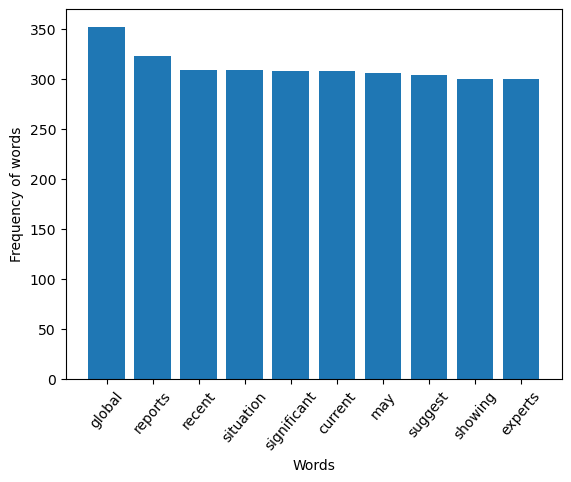

In [59]:
common = word_freq.most_common(10)

words = [w[0] for w in common]
counts = [w[1] for w in common]

# Create figure and axis
fig, ax = plt.subplots()
# Plot bar chart
ax.bar(words, counts)
# Customize
plt.xticks(rotation=50)
ax.set_ylabel("Frequency of words")
ax.set_xlabel("Words")
# Show plot
plt.show()

# Save the figure
fig.savefig("top_10_frequent_words.png")

### Insight : The top 10 common words with highest frequency are  
1. global
   
2. reports

3. recent

4. situtation

5. significant

6. current

7. may

8. suggest

9. showing

10. experts

### 5 random keywords chosen from frequency analysis : intelligence , ecosystem , influence , impact , government 

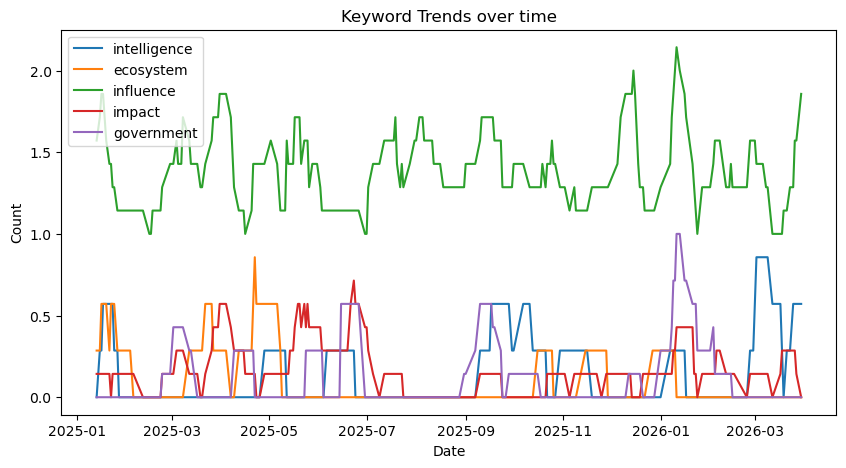

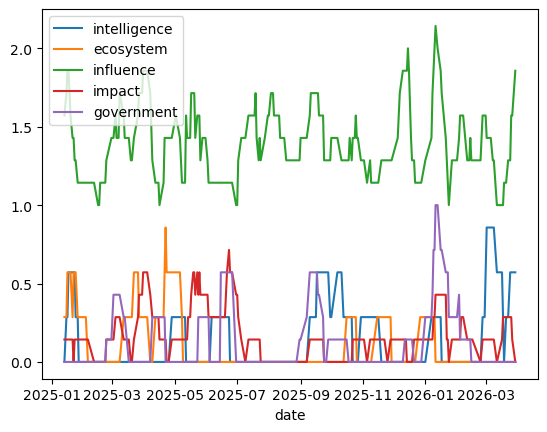

In [60]:
keywords = ["intelligence" , "ecosystem", "influence" ,"impact", "government"]

for k in keywords:
    news_data[k]  = news_data['final text'].apply(lambda x: x.count(k))
trend = news_data.groupby(news_data['date'].dt.date)[keywords].sum()
trend_graph = trend.rolling(window = 7).mean()
trend_graph.plot(figsize = (10,5))
plt.title("Keyword Trends over time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.show()

#Saving the plot 
plot = trend_graph.plot()
fig = plot.get_figure()
fig.savefig("keywords_trend.png")


## Q2. Which keyword shows the highest growth trend over time?

#### Influence shows the highest growth. It stays consistently higher than other keywords and increases with noticeable peaks toward the end, indicating rising importance over time.
#### Additionally, it has fewer zero or inactive periods, meaning it remains relevant throughout the entire timeline rather than appearing only during specific events. 
#### The upward movement combined with repeated spikes suggests both sustained interest and periodic surges, likely driven by ongoing discussions as well as key events. 
#### Compared to other keywords, it demonstrates both consistency and growth, making it the most prominent and steadily evolving topic in the dataset.

## Q3. Which keyword shows a declining trend?

#### Ecosystem shows a declining trend. It appears more in the earlier months but gradually drops off and becomes nearly absent later.
#### In the first half of the timeline, “ecosystem” has frequent small spikes, meaning it was discussed occasionally alongside other topics. 
#### However, as time progresses, these spikes become less frequent and weaker, eventually leading to long periods with no activity at all.
#### This pattern suggests that the keyword is losing relevance over time. Instead of steady coverage, it shifts from intermittent presence → rare mentions → near disappearance.
#### A likely reason could be that discussions moved toward more specific or emerging terms, causing “ecosystem” to be used less often in news coverage.

## Q4.Are there any sudden spike in certain topics?

#### Yes, there are sudden spikes:
#### Influence has multiple sharp peaks (especially later in the timeline).
#### Government shows a clear spike around early 2026.
#### Intelligence also spikes toward the end.

## 5. Which topic is most consistent over time?

In [61]:
news_data.head()

,date,title,content,source,clean title,clean content,final text,keyword count,month,ai,economy,cricket,health,technology,intelligence,ecosystem,influence,impact,government
0,2025-05-11,education: light able sport career six discuss...,education is showing significant market shift ...,economic times,education light able sport career six discuss ...,education showing significant market shift rec...,education light able sport career six discuss ...,0,2025-05,1,0,0,0,0,0,0,1,0,0
1,2025-04-13,stock market: join tough former nice quite.,stock market is showing significant rise in re...,reuters,stock market join tough former nice quite,stock market showing significant rise recent r...,stock market join tough former nice quitestock...,0,2025-04,2,0,0,0,0,0,0,1,0,0
2,2025-04-15,elections: citizen item particularly short wha...,elections is showing significant growth in rec...,economic times,elections citizen item particularly short what...,elections showing significant growth recent re...,elections citizen item particularly short what...,0,2025-04,0,0,0,0,0,0,0,1,0,0
3,2025-09-07,jobs market: themselves business coach million...,jobs market is showing significant growth in r...,ndtv,jobs market business coach million always,jobs market showing significant growth recent ...,jobs market business coach million alwaysjobs ...,0,2025-09,0,0,0,0,0,0,0,1,0,0
4,2025-03-08,space exploration: eat wonder political return...,space exploration is showing significant growt...,bbc news,space exploration eat wonder political return ...,space exploration showing significant growth r...,space exploration eat wonder political return ...,0,2025-03,1,0,0,0,0,0,0,1,0,0


Top Topics : Index(['global', 'elections', 'jobs', 'education', 'cricket'], dtype='object', name='topic')



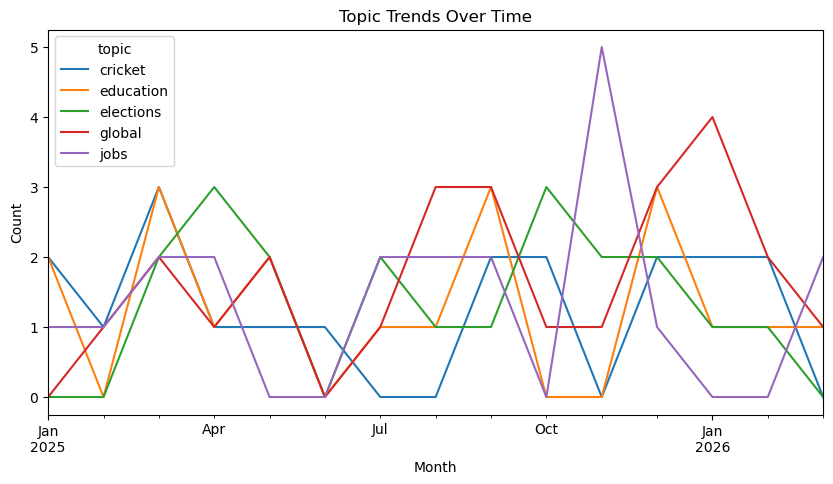

Stability (low = more consistent):
topic
cricket      0.961150
elections    1.046536
education    1.099784
global       1.175139
jobs         1.345185
dtype: float64


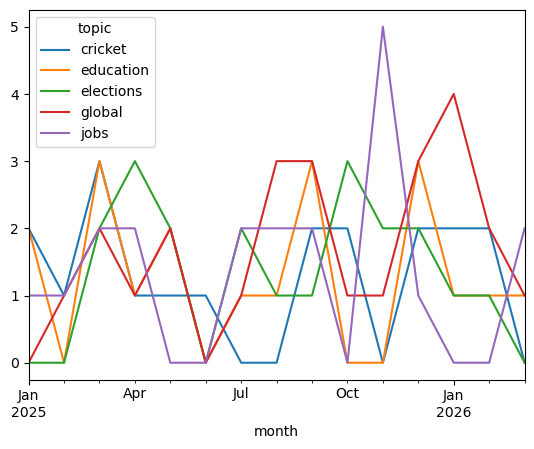

In [62]:

news_data['month'] = news_data['date'].dt.to_period('M')

# extract topic from clean_title (first word before space)
news_data['topic'] = news_data['clean title'].apply(lambda x: x.split()[0])

# get top topics
top_topics = news_data['topic'].value_counts().head(5).index

print("Top Topics :", top_topics)
print()
# filter only top topics
news_data_filtered = news_data[news_data['topic'].isin(top_topics)]

# count per month
trend = news_data_filtered.groupby(['month', 'topic']).size().unstack(fill_value=0)

# plot
trend.plot(figsize=(10,5))
plt.title("Topic Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

# find most stable topic (low variation)
print("Stability (low = more consistent):")
print(trend.std().sort_values())

#Saving the plot 
plot = trend.plot()
fig = plot.get_figure()
fig.savefig("steady_topic_trend.png")

#### Cricket : most consistent topic (steady presence)
#### Elections, Education : moderately stable (some fluctuations)
#### Global, Jobs : highly variable (spikes & drops)
#### Event-driven trends : spikes indicate specific events/news
#### Overall focus : mix of steady topics and dynamic/event-based coverage

## 6. What insights can be drawn about overall news focus?

#### The analysis reveals that news coverage is dominated by a mix of consistent and dynamic topics. 
#### Cricket emerges as the most stable topic, showing steady presence over time, while elections and education maintain moderate consistency. 
#### In contrast, topics like global issues and jobs exhibit significant fluctuations, indicating event-driven reporting. 
#### Word frequency analysis highlights key themes, and trend analysis shows how public focus shifts over time. 
#### Overall, the project demonstrates how NLP techniques can effectively uncover patterns and insights from news data.

### Optional : cleaning the dataset after interpretation , to save only neccessary data into cleaned file

In [63]:
news_data.head()

,date,title,content,source,clean title,clean content,final text,keyword count,month,ai,economy,cricket,health,technology,intelligence,ecosystem,influence,impact,government,topic
0,2025-05-11,education: light able sport career six discuss...,education is showing significant market shift ...,economic times,education light able sport career six discuss ...,education showing significant market shift rec...,education light able sport career six discuss ...,0,2025-05,1,0,0,0,0,0,0,1,0,0,education
1,2025-04-13,stock market: join tough former nice quite.,stock market is showing significant rise in re...,reuters,stock market join tough former nice quite,stock market showing significant rise recent r...,stock market join tough former nice quitestock...,0,2025-04,2,0,0,0,0,0,0,1,0,0,stock
2,2025-04-15,elections: citizen item particularly short wha...,elections is showing significant growth in rec...,economic times,elections citizen item particularly short what...,elections showing significant growth recent re...,elections citizen item particularly short what...,0,2025-04,0,0,0,0,0,0,0,1,0,0,elections
3,2025-09-07,jobs market: themselves business coach million...,jobs market is showing significant growth in r...,ndtv,jobs market business coach million always,jobs market showing significant growth recent ...,jobs market business coach million alwaysjobs ...,0,2025-09,0,0,0,0,0,0,0,1,0,0,jobs
4,2025-03-08,space exploration: eat wonder political return...,space exploration is showing significant growt...,bbc news,space exploration eat wonder political return ...,space exploration showing significant growth r...,space exploration eat wonder political return ...,0,2025-03,1,0,0,0,0,0,0,1,0,0,space


In [64]:
 news_data.drop(columns=['intelligence','ecosystem','influence','impact','government'], inplace = True)

In [65]:
news_data.head()

,date,title,content,source,clean title,clean content,final text,keyword count,month,ai,economy,cricket,health,technology,topic
0,2025-05-11,education: light able sport career six discuss...,education is showing significant market shift ...,economic times,education light able sport career six discuss ...,education showing significant market shift rec...,education light able sport career six discuss ...,0,2025-05,1,0,0,0,0,education
1,2025-04-13,stock market: join tough former nice quite.,stock market is showing significant rise in re...,reuters,stock market join tough former nice quite,stock market showing significant rise recent r...,stock market join tough former nice quitestock...,0,2025-04,2,0,0,0,0,stock
2,2025-04-15,elections: citizen item particularly short wha...,elections is showing significant growth in rec...,economic times,elections citizen item particularly short what...,elections showing significant growth recent re...,elections citizen item particularly short what...,0,2025-04,0,0,0,0,0,elections
3,2025-09-07,jobs market: themselves business coach million...,jobs market is showing significant growth in r...,ndtv,jobs market business coach million always,jobs market showing significant growth recent ...,jobs market business coach million alwaysjobs ...,0,2025-09,0,0,0,0,0,jobs
4,2025-03-08,space exploration: eat wonder political return...,space exploration is showing significant growt...,bbc news,space exploration eat wonder political return ...,space exploration showing significant growth r...,space exploration eat wonder political return ...,0,2025-03,1,0,0,0,0,space


In [66]:
news_data.to_csv("cleaned_news_data.csv", index=False)